# Lab 6 — Deep Learning for NLP

**Student name:** Faisal AL Zahrani  
**Student ID:** 2230000363

**Objective:** Classify Yelp reviews as negative (0) or positive (1), first with TF-IDF and then with Word2Vec review vectors and a deeper PyTorch network.

The original ten worked sections and both tasks are completed in order. Results below are produced by the supplied dataset and saved with the notebook.

# Deep Learning for NLP

**Deep Learning** is a type of Machine Learning that uses **Neural Networks with multiple layers** to learn patterns from data.

Deep Learning can be used in NLP tasks such as:
- Text Classification
- Sentiment Analysis
- Question Answering

In this lab, we will build a **deep learning model** to classify Yelp restaurant reviews as:

- **0 = Negative**
- **1 = Positive**

### Neural-network overview

Each review is converted to a numerical vector, passed through hidden layers with ReLU activations, and mapped to one output logit. During evaluation, sigmoid converts that logit to an estimated positive-class probability.

**TF-IDF example:** up to 1,000 input features → 64 → 32 → 1  
**Word2Vec task:** 200 input features → 128 → 64 → 32 → 1

The source's two illustrations could not be retrieved during preparation. Their original links are preserved: [illustration 1](https://drive.google.com/uc?export=view&id=1rUaLO1wEOcUZ10Kwd0nUvS3jQzrqoOcI), [illustration 2](https://drive.google.com/uc?export=view&id=1XKPTKwxmIpP5cZIkDajlai6aI9jUX-C8). The solution does not require these images.

### Setup and implementation notes

Use **Python 3.12** with the accompanying `requirements.txt`, and run cells in order. Keep the supplied Yelp file inside `data/` or next to this notebook. All examples run on a CPU; no model or dataset download is needed after installing the dependencies.

Two source-code errors are corrected: preprocessing is applied outside the function, and gradients are cleared before each optimizer update. The split uses `stratify=y`, as described in the source. All 1,000 supplied rows are retained; duplicated cleaned text is audited for overlap across the split.

Both representations are fitted on training reviews only and use the same held-out test reviews. The seed is 42. Each neural-network epoch uses one full-training-batch update, matching the worked example. Test performance is evaluated after the prescribed training epochs; it is not used to select a model.

In [1]:
import importlib.util
import importlib.metadata
import random
import sys
from IPython.display import display, Markdown

required_modules = ['pandas', 'numpy', 'scipy', 'sklearn', 'matplotlib', 'torch', 'gensim']
missing = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing:
    raise RuntimeError('Install requirements.txt in a Python 3.12 environment, then select that kernel. Missing: ' + ', '.join(missing))

import numpy as np
import torch
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
print('Python:', sys.version.split()[0])
for package in ['pandas', 'numpy', 'scipy', 'scikit-learn', 'matplotlib', 'torch', 'gensim']:
    print(f'{package}: {importlib.metadata.version(package)}')
print('Execution device: CPU')

Python: 3.12.14
pandas: 3.0.1
numpy: 2.3.5
scipy: 1.18.1
scikit-learn: 1.8.0
matplotlib: 3.10.7
torch: 2.14.1+cpu
gensim: 4.4.0
Execution device: CPU


## 1. Load the Yelp Dataset

Each row contains:

- a restaurant review
- its sentiment label


In [2]:
from pathlib import Path
import csv
import hashlib
import pandas as pd

data_candidates = [Path('data/07-yelp-dataset.txt'), Path('07-yelp-dataset.txt')]
DATA_PATH = next((p for p in data_candidates if p.is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Keep 07-yelp-dataset.txt in data/ or beside this notebook.')

data_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
assert data_sha256 == 'c76468b7b5c6e56a0804d728345c5f84aa2142ddb214420f61cc9cfd4c00d2ea'
df = pd.read_csv(DATA_PATH, sep='\t', names=['review', 'label'],
                 encoding='utf-8', quoting=csv.QUOTE_NONE)
assert df.shape == (1000, 2)
assert not df.isna().any().any()
assert set(df.label) == {0, 1}
raw_reviews = df['review'].copy()
print('Number of reviews:', len(df))
display(df.head())

Number of reviews: 1000


,review,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [3]:
class_counts = df['label'].value_counts().sort_index()
display(class_counts.rename_axis('Label (0=Negative, 1=Positive)').to_frame('Reviews'))
assert class_counts.to_dict() == {0: 500, 1: 500}

,Reviews
"Label (0=Negative, 1=Positive)",
0,500
1,500


## 2. Preprocessing the Dataset

In [4]:
import re

def preprocess_text(text):
    # Match the lab's preprocessing rules.
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing outside the function, after its return statement.
df['review'] = df['review'].apply(preprocess_text)
assert not df['review'].eq('').any()
duplicate_review_count = int(df['review'].duplicated().sum())
print('Repeated cleaned reviews beyond the first occurrence:', duplicate_review_count)
display(pd.DataFrame({'Original review': raw_reviews.head(),
                      'Cleaned review': df['review'].head()}))

Repeated cleaned reviews beyond the first occurrence: 5


,Original review,Cleaned review
0,Wow... Loved this place.,wow loved this place
1,Crust is not good.,crust is not good
2,Not tasty and the texture was just nasty.,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,the selection on the menu was great and so wer...


## 3. Split the Data

We divide the dataset into:

- **80% training data** — used to train the model
- **20% testing data** — used to evaluate the model

`stratify=y` keeps the proportion of positive and negative reviews similar in both sets.

In [5]:
from sklearn.model_selection import train_test_split

X = df['review']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
assert set(X_train.index).isdisjoint(X_test.index)
shared_review_count = len(set(X_train).intersection(X_test))
print('Training reviews:', len(X_train))
print('Testing reviews:', len(X_test))
print('Identical cleaned review texts shared across splits:', shared_review_count)
display(pd.DataFrame({'Training': y_train.value_counts().sort_index(),
                      'Testing': y_test.value_counts().sort_index()})
        .rename_axis('Label (0=Negative, 1=Positive)'))
assert len(X_train) == 800 and len(X_test) == 200
assert shared_review_count == 0

Training reviews: 800
Testing reviews: 200
Identical cleaned review texts shared across splits: 0


,Training,Testing
"Label (0=Negative, 1=Positive)",,
0,400,100
1,400,100


## 4. Convert Text to TF-IDF Vectors

A neural network cannot directly understand text.

**TF-IDF converts each review into a vector of numbers.**


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Learn vocabulary and IDF from training reviews only.
tfidf = TfidfVectorizer(max_features=1000, lowercase=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print('Training TF-IDF shape:', X_train_tfidf.shape)
print('Testing TF-IDF shape:', X_test_tfidf.shape)

Training TF-IDF shape: (800, 1000)
Testing TF-IDF shape: (200, 1000)


## 5. Convert the Data to PyTorch Tensors

PyTorch neural networks work with **tensors**.

In [7]:
import torch
import torch.nn as nn

# All features and binary targets use float32 on the CPU.
X_train_tensor = torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_tfidf.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1, 1)
print('Features:', tuple(X_train_tensor.shape), tuple(X_test_tensor.shape))
print('Targets: ', tuple(y_train_tensor.shape), tuple(y_test_tensor.shape))

Features: (800, 1000) (200, 1000)
Targets:  (800, 1) (200, 1)


## 6. Build a Simple Neural Network

Our network has:

1. **Input layer** — receives the TF-IDF features
2. **Hidden layer** — learns useful patterns
3. **ReLU activation** — adds non-linearity
4. **Output layer** — produces one value for binary classification

We do **not** put `Sigmoid` inside the model because `BCEWithLogitsLoss` applies it internally in a numerically stable way.

In [8]:
torch.manual_seed(RANDOM_SEED)
input_size = X_train_tensor.shape[1]
model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Linear(in_features=1000, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
Trainable parameters: 66177


## 7. Choose the Loss Function and Optimizer

- **BCEWithLogitsLoss** is used for binary classification.
To measure the model’s mistakes.
- **Adam** is responsible for changing the model's weights so that the loss becomes smaller.

In [9]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

## 8. Train the Neural Network

One **epoch** means the model has seen the full training dataset once.

For every epoch:

1. Make predictions
2. Calculate the loss
3. Calculate gradients with backpropagation
4. Update the weights

In [10]:
epochs = 10
tfidf_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()  # Clear gradients before every update.
    outputs = model(X_train_tensor)
    loss = loss_function(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    tfidf_losses.append(loss.item())
    print(f'Epoch {epoch + 1:2d}/{epochs} - Training loss: {loss.item():.6f}')

assert np.isfinite(tfidf_losses).all()

Epoch  1/10 - Training loss: 0.693181
Epoch  2/10 - Training loss: 0.688054
Epoch  3/10 - Training loss: 0.675259
Epoch  4/10 - Training loss: 0.654202
Epoch  5/10 - Training loss: 0.624162
Epoch  6/10 - Training loss: 0.585877
Epoch  7/10 - Training loss: 0.539337
Epoch  8/10 - Training loss: 0.484886
Epoch  9/10 - Training loss: 0.423195
Epoch 10/10 - Training loss: 0.357652


## 9. Evaluate the Model

The model outputs raw scores called **logits**.

We apply `sigmoid` to convert them to probabilities between 0 and 1.

- Probability **≥ 0.5 → Positive (1)**
- Probability **< 0.5 → Negative (0)**

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probabilities = torch.sigmoid(test_logits)
    predictions = (test_probabilities >= 0.5).int().numpy().ravel()
    tfidf_test_loss = loss_function(test_logits, y_test_tensor).item()
    tfidf_train_predictions = (torch.sigmoid(model(X_train_tensor)) >= 0.5).int().numpy().ravel()

accuracy = accuracy_score(y_test, predictions)
tfidf_train_accuracy = accuracy_score(y_train, tfidf_train_predictions)
print(f'Training accuracy: {tfidf_train_accuracy:.3f}')
print(f'Test accuracy:     {accuracy:.3f} ({accuracy:.1%})')
print(f'Test loss:         {tfidf_test_loss:.6f}')

Training accuracy: 0.969
Test accuracy:     0.755 (75.5%)
Test loss:         0.496936


## 10. Classification Report and Confusion Matrix

The classification report shows:

- **Precision**
- **Recall**
- **F1-score**

The confusion matrix shows how many reviews were classified correctly and incorrectly.

In [12]:
print('Classification Report — TF-IDF:')
print(classification_report(y_test, predictions, labels=[0, 1],
                            target_names=['Negative', 'Positive'], digits=3, zero_division=0))
tfidf_confusion = confusion_matrix(y_test, predictions, labels=[0, 1])
display(pd.DataFrame(tfidf_confusion, index=['Actual negative', 'Actual positive'],
                      columns=['Predicted negative', 'Predicted positive']))
assert tfidf_confusion.sum() == len(y_test)
assert np.isclose(np.trace(tfidf_confusion) / len(y_test), accuracy)

Classification Report — TF-IDF:
              precision    recall  f1-score   support

    Negative      0.807     0.670     0.732       100
    Positive      0.718     0.840     0.774       100

    accuracy                          0.755       200
   macro avg      0.763     0.755     0.753       200
weighted avg      0.763     0.755     0.753       200



,Predicted negative,Predicted positive
Actual negative,67,33
Actual positive,16,84


## Task 1 – Represent Reviews Using Word2Vec

In the previous part of the lab, TF-IDF was used to convert each review into numerical features.
Now, use Word2Vec instead.

Requirements:
Tokenize the training and testing reviews.
Train a Word2Vec model using the training reviews.
Use:
vector_size = 200
window = 5
min_count = 1
sg = 1

Convert each review into a single vector.
Convert the resulting vectors into PyTorch tensors.


**Task 1 — Approach.** Tokenize the cleaned training and testing reviews separately, train a 200-dimensional Skip-gram model on training reviews only, then take the mean of the known word vectors in each review. Ignore unseen test words; use a zero vector if no known words remain. Averaging produces one fixed-length vector but loses word order. Convert the two arrays to `float32` PyTorch tensors.

In [13]:
from gensim.models import Word2Vec
import zlib

# Whitespace tokenization follows the already lowercased, punctuation-free text.
train_tokens = [review.split() for review in X_train]
test_tokens = [review.split() for review in X_test]

def stable_hash(word):
    return zlib.crc32(word.encode('utf-8'))

# Training reviews alone determine the vocabulary and learned embeddings.
# Explicitly retain Gensim's default five Word2Vec training epochs.
word2vec = Word2Vec(
    sentences=train_tokens, vector_size=200, window=5, min_count=1, sg=1,
    seed=RANDOM_SEED, workers=1, epochs=5, hashfxn=stable_hash,
)

def review_vector(tokens, embedding_model):
    known_words = [word for word in tokens if word in embedding_model.wv]
    if not known_words:
        return np.zeros(embedding_model.vector_size, dtype=np.float32)
    return embedding_model.wv[known_words].mean(axis=0).astype(np.float32)

X_train_w2v = np.vstack([review_vector(tokens, word2vec) for tokens in train_tokens])
X_test_w2v = np.vstack([review_vector(tokens, word2vec) for tokens in test_tokens])
X_train_w2v_tensor = torch.tensor(X_train_w2v, dtype=torch.float32)
X_test_w2v_tensor = torch.tensor(X_test_w2v, dtype=torch.float32)

training_vocabulary = {word for review in train_tokens for word in review}
test_vocabulary = {word for review in test_tokens for word in review}
test_oov_vocabulary = test_vocabulary - training_vocabulary
test_token_count = sum(map(len, test_tokens))
test_oov_token_count = sum(word not in word2vec.wv for review in test_tokens for word in review)
test_zero_vector_count = int(np.all(X_test_w2v == 0, axis=1).sum())

assert set(word2vec.wv.key_to_index) == training_vocabulary
assert not test_oov_vocabulary.intersection(word2vec.wv.key_to_index)
assert word2vec.corpus_count == len(X_train)
assert (word2vec.vector_size, word2vec.window, word2vec.min_count, word2vec.sg) == (200, 5, 1, 1)
assert X_train_w2v.shape == (800, 200) and X_test_w2v.shape == (200, 200)
assert np.isfinite(X_train_w2v).all() and np.isfinite(X_test_w2v).all()
assert np.all(review_vector([], word2vec) == 0)
assert np.all(review_vector(['__unseen_token__'], word2vec) == 0)

print('Word2Vec vocabulary:', len(word2vec.wv))
print('Training review vectors:', tuple(X_train_w2v_tensor.shape))
print('Testing review vectors: ', tuple(X_test_w2v_tensor.shape))
print(f'Unseen test tokens: {test_oov_token_count}/{test_token_count} ({test_oov_token_count / test_token_count:.1%})')
print('Test reviews represented by a zero vector:', test_zero_vector_count)
display(pd.DataFrame(X_train_w2v[:5, :8], index=X_train.index[:5],
                      columns=[f'Dimension {i+1}' for i in range(8)]))

Word2Vec vocabulary: 1787
Training review vectors: (800, 200)
Testing review vectors:  (200, 200)
Unseen test tokens: 281/2157 (13.0%)
Test reviews represented by a zero vector: 0


,Dimension 1,Dimension 2,Dimension 3,Dimension 4,Dimension 5,Dimension 6,Dimension 7,Dimension 8
652,0.115274,0.042151,0.007251,0.066766,-0.048526,0.007302,0.098301,0.155013
679,0.122923,0.046312,0.005479,0.069434,-0.052932,0.006018,0.105328,0.168139
465,0.129968,0.050723,0.007052,0.073093,-0.056394,0.007586,0.110134,0.176170
885,0.105514,0.040337,0.004884,0.062474,-0.045220,0.005246,0.090295,0.142222
521,0.106832,0.037655,0.004829,0.061603,-0.045889,0.005459,0.091133,0.142746


## Task 2 – Build a Different Neural Network

Use the Word2Vec vectors from Task 1 as the input to a new neural network.
Your network must contain:
An input layer
Three hidden layers
ReLU activation functions
One output neuron
Use the following architecture:

Input
   
   ↓

128 neurons
   
   ↓

64 neurons
   
   ↓

32 neurons
   
   ↓

1 output neuron

Train the model using:
, BCEWithLogitsLoss
, Adam optimizer
, Learning rate = 0.001
, 15 epochs.
Then calculate the test accuracy.

**Task 2 — Approach.** Use the 200-dimensional review vectors with exactly three hidden layers of 128, 64, and 32 neurons, each followed by ReLU. The single output neuron returns a logit. Train with `BCEWithLogitsLoss`, Adam at **0.001**, and **15 epochs**. At evaluation, apply sigmoid and classify scores of at least 0.5 as positive.

In [14]:
torch.manual_seed(RANDOM_SEED)
w2v_classifier = nn.Sequential(
    nn.Linear(200, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)
print(w2v_classifier)
print('Trainable parameters:', sum(p.numel() for p in w2v_classifier.parameters()))

w2v_loss_function = nn.BCEWithLogitsLoss()
w2v_optimizer = torch.optim.Adam(w2v_classifier.parameters(), lr=0.001)
w2v_epochs = 15
w2v_losses = []

for epoch in range(w2v_epochs):
    w2v_classifier.train()
    w2v_optimizer.zero_grad()
    logits = w2v_classifier(X_train_w2v_tensor)
    loss = w2v_loss_function(logits, y_train_tensor)
    loss.backward()
    w2v_optimizer.step()
    w2v_losses.append(loss.item())
    print(f'Epoch {epoch + 1:2d}/{w2v_epochs} - Training loss: {loss.item():.6f}')

w2v_classifier.eval()
with torch.no_grad():
    w2v_test_logits = w2v_classifier(X_test_w2v_tensor)
    w2v_probabilities = torch.sigmoid(w2v_test_logits).numpy().ravel()
    w2v_predictions = (w2v_probabilities >= 0.5).astype(np.int64)
    w2v_test_loss = w2v_loss_function(w2v_test_logits, y_test_tensor).item()
    w2v_train_predictions = (torch.sigmoid(w2v_classifier(X_train_w2v_tensor)) >= 0.5).int().numpy().ravel()

w2v_accuracy = accuracy_score(y_test, w2v_predictions)
w2v_train_accuracy = accuracy_score(y_train, w2v_train_predictions)
print(f'\nTraining accuracy: {w2v_train_accuracy:.3f}')
print(f'Test accuracy:     {w2v_accuracy:.3f} ({w2v_accuracy:.1%})')
print(f'Test loss:         {w2v_test_loss:.6f}')
assert np.isfinite(w2v_losses).all()
assert len(w2v_losses) == 15
assert [layer.out_features for layer in w2v_classifier if isinstance(layer, nn.Linear)] == [128, 64, 32, 1]

Sequential(
  (0): Linear(in_features=200, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)
Trainable parameters: 36097
Epoch  1/15 - Training loss: 0.695813
Epoch  2/15 - Training loss: 0.695315
Epoch  3/15 - Training loss: 0.694942
Epoch  4/15 - Training loss: 0.694617
Epoch  5/15 - Training loss: 0.694317
Epoch  6/15 - Training loss: 0.694068
Epoch  7/15 - Training loss: 0.693842
Epoch  8/15 - Training loss: 0.693667
Epoch  9/15 - Training loss: 0.693519
Epoch 10/15 - Training loss: 0.693396
Epoch 11/15 - Training loss: 0.693316
Epoch 12/15 - Training loss: 0.693264
Epoch 13/15 - Training loss: 0.693243
Epoch 14/15 - Training loss: 0.693236
Epoch 15/15 - Training loss: 0.693236

Training accuracy: 0.505
Test accuracy:     0.490 (49.0%)
Test loss:         0.693391


### Task 2 — Evaluation and comparison

The following report and matrix use the same class order as the worked example: **negative, positive**. Matrix rows are true classes and columns are predicted classes. The plots show training loss and held-out classification counts.

In [15]:
print('Classification Report — Word2Vec:')
print(classification_report(y_test, w2v_predictions, labels=[0, 1],
                            target_names=['Negative', 'Positive'], digits=3, zero_division=0))
w2v_confusion = confusion_matrix(y_test, w2v_predictions, labels=[0, 1])
display(pd.DataFrame(w2v_confusion, index=['Actual negative', 'Actual positive'],
                      columns=['Predicted negative', 'Predicted positive']))
comparison = pd.DataFrame({
    'Representation': ['TF-IDF', 'Mean Word2Vec'],
    'Input dimensions': [input_size, 200],
    'Hidden layers': ['64 → 32', '128 → 64 → 32'],
    'Epochs': [epochs, w2v_epochs],
    'Learning rate': [0.01, 0.001],
    'Training accuracy': [tfidf_train_accuracy, w2v_train_accuracy],
    'Test accuracy': [accuracy, w2v_accuracy],
    'Test loss': [tfidf_test_loss, w2v_test_loss],
})
display(comparison.round(4))
assert w2v_confusion.sum() == len(y_test)
assert np.isclose(np.trace(w2v_confusion) / len(y_test), w2v_accuracy)

Classification Report — Word2Vec:
              precision    recall  f1-score   support

    Negative      0.495     0.980     0.658       100
    Positive      0.000     0.000     0.000       100

    accuracy                          0.490       200
   macro avg      0.247     0.490     0.329       200
weighted avg      0.247     0.490     0.329       200



,Predicted negative,Predicted positive
Actual negative,98,2
Actual positive,100,0


,Representation,Input dimensions,Hidden layers,Epochs,Learning rate,Training accuracy,Test accuracy,Test loss
0,TF-IDF,1000,64 → 32,10,0.010,0.9688,0.755,0.4969
1,Mean Word2Vec,200,128 → 64 → 32,15,0.001,0.5050,0.490,0.6934


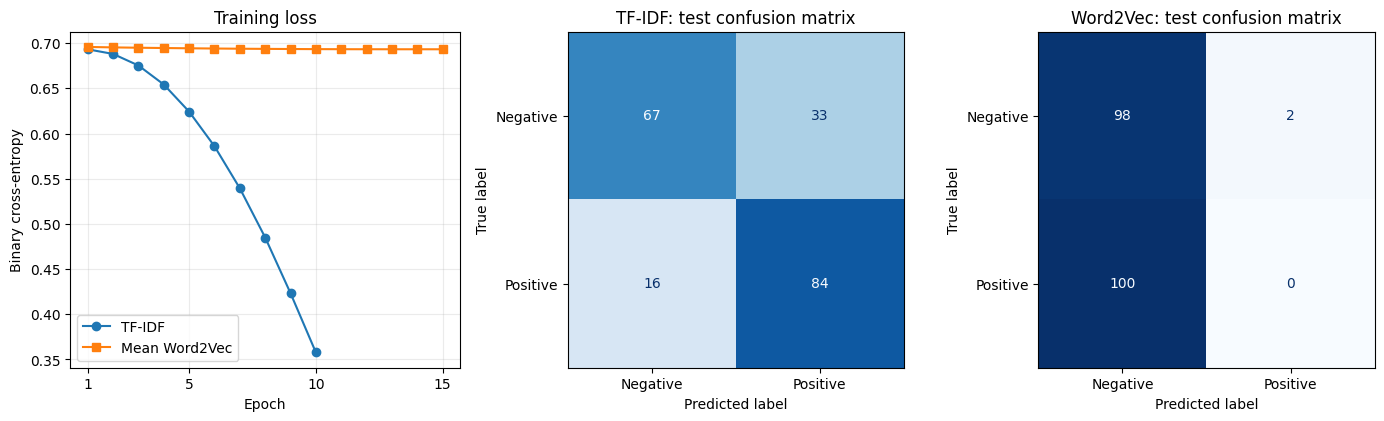

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(14, 4.1), constrained_layout=True)
axes[0].plot(range(1, epochs + 1), tfidf_losses, marker='o', label='TF-IDF')
axes[0].plot(range(1, w2v_epochs + 1), w2v_losses, marker='s', label='Mean Word2Vec')
axes[0].set(title='Training loss', xlabel='Epoch', ylabel='Binary cross-entropy')
axes[0].set_xticks([1, 5, 10, 15])
axes[0].legend()
axes[0].grid(alpha=0.25)
for ax, matrix, title in zip(axes[1:], [tfidf_confusion, w2v_confusion],
                             ['TF-IDF: test confusion matrix', 'Word2Vec: test confusion matrix']):
    ConfusionMatrixDisplay(matrix, display_labels=['Negative', 'Positive']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d', im_kw={'vmin': 0, 'vmax': 100}
    )
    ax.set_title(title)
plt.show()

In [17]:
majority_baseline = float(y_test.value_counts(normalize=True).max())
interpretation = (
    f'**Observed results:** TF-IDF test accuracy is **{accuracy:.1%}** and mean Word2Vec test accuracy is '
    f'**{w2v_accuracy:.1%}** on the same **{len(y_test)}** reviews. '
    f'The majority-class baseline is **{majority_baseline:.1%}**. '
    f'Word2Vec has **{len(word2vec.wv):,}** training-vocabulary words, with '
    f'**{test_oov_token_count / test_token_count:.1%}** of test-token occurrences unseen during embedding training.\n\n'
    f'The Word2Vec network reaches **{w2v_train_accuracy:.1%}** training accuracy and '
    f'**{w2v_accuracy:.1%}** test accuracy after 15 full-batch updates. '
    'Performance near the majority baseline on both sets indicates that it has learned little class separation in this run. '
    f'The TF-IDF model reaches **{tfidf_train_accuracy:.1%}** training accuracy, '
    'so its training-to-test gap also highlights limited generalization.\n\n'
    'This is a comparison of the two prescribed pipelines, not an isolated test of representation quality: '
    'the hidden layers, learning rates, and epoch counts also differ. Training Word2Vec from scratch on 800 short '
    'reviews provides limited context, and mean pooling discards word order, including the order of negation. '
    'A lower Word2Vec score is therefore possible; a deeper model is not guaranteed to improve accuracy. '
    'Future experiments could use a separate validation split to choose training settings or investigate pretrained '
    'embeddings, while keeping the test set untouched.'
)
if w2v_accuracy <= majority_baseline:
    interpretation += '\n\nThe prescribed Word2Vec pipeline did not outperform the majority-class baseline in this run; this result is reported as observed.'
display(Markdown(interpretation))

**Observed results:** TF-IDF test accuracy is **75.5%** and mean Word2Vec test accuracy is **49.0%** on the same **200** reviews. The majority-class baseline is **50.0%**. Word2Vec has **1,787** training-vocabulary words, with **13.0%** of test-token occurrences unseen during embedding training.

The Word2Vec network reaches **50.5%** training accuracy and **49.0%** test accuracy after 15 full-batch updates. Performance near the majority baseline on both sets indicates that it has learned little class separation in this run. The TF-IDF model reaches **96.9%** training accuracy, so its training-to-test gap also highlights limited generalization.

This is a comparison of the two prescribed pipelines, not an isolated test of representation quality: the hidden layers, learning rates, and epoch counts also differ. Training Word2Vec from scratch on 800 short reviews provides limited context, and mean pooling discards word order, including the order of negation. A lower Word2Vec score is therefore possible; a deeper model is not guaranteed to improve accuracy. Future experiments could use a separate validation split to choose training settings or investigate pretrained embeddings, while keeping the test set untouched.

The prescribed Word2Vec pipeline did not outperform the majority-class baseline in this run; this result is reported as observed.

### Completion checklist

- **Worked example (sections 1–10):** data loading, preprocessing, stratified split, training-only TF-IDF, tensors, neural-network construction, loss/optimizer, ten-epoch training, accuracy, classification report, and confusion matrix.
- **Task 1:** separate tokenization, training-only Skip-gram (`vector_size=200`, `window=5`, `min_count=1`, `sg=1`), mean review vectors, unseen-word handling, and PyTorch tensors.
- **Task 2:** 200 → 128 → 64 → 32 → 1 network, ReLU, `BCEWithLogitsLoss`, Adam (`lr=0.001`), 15 training epochs, and test accuracy.

### References

- Dataset: the **07-yelp-dataset.txt** file supplied with this lab, preserved unchanged.
- [PyTorch training loop and gradient reset](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html)
- [PyTorch BCEWithLogitsLoss](https://docs.pytorch.org/docs/2.14/generated/torch.nn.BCEWithLogitsLoss.html)
- [Gensim Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html)